# Calculate the Enhanced Combined Drought Index

In [1]:
import json
import os

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray
import xarray as xr
from deafrica_tools.spatial import add_geobox
from odc.geo.geom import Geometry
from odc.geo.xr import rasterize
from pyarrow.parquet import read_table as pq_read_table

## Load the drought indices data

In [2]:
vector_file = "https://raw.githubusercontent.com/Mondieki/kenya-counties-subcounties/master/geojson/baringo.json"

In [3]:
PARQUET_META_KEY = b"xarray.metadata"
output_dir = "results"

In [4]:
# Load the area of interest
aoi_gdf = gpd.read_file(vector_file)
geopolygon = Geometry(geom=aoi_gdf.geometry.iloc[0], crs=aoi_gdf.crs)

In [5]:
VDI_path = os.path.join(output_dir, "VDI.parquet")
TDI_path = os.path.join(output_dir, "TDI.parquet")
PDI_path = os.path.join(output_dir, "PDI.parquet")

In [6]:
def read_table(path: str) -> pd.DataFrame:
    """Read a Parquet file with Conflux metadata.

    Arguments
    ---------
    path : str
        Path to Parquet file.

    Returns
    -------
    pd.DataFrame
        DataFrame with attrs set.
    """
    table = pq_read_table(path)
    df = table.to_pandas()
    meta_json = table.schema.metadata[PARQUET_META_KEY]
    metadata = json.loads(meta_json)
    for key, val in metadata.items():
        df.attrs[key] = val
    return df

In [7]:
VDI_df = read_table(VDI_path)
VDI = VDI_df.to_xarray()
VDI = add_geobox(VDI, crs=VDI_df.attrs["crs"])
VDI

<xarray.Dataset>
Dimensions:      (dekad: 374, y: 49, x: 20)
Coordinates:
  * dekad        (dekad) datetime64[ns] 2014-01-01 2014-01-11 ... 2024-05-11
  * y            (y) float64 -2.75e+04 -2.25e+04 ... 2.075e+05 2.125e+05
  * x            (x) float64 3.428e+06 3.432e+06 ... 3.518e+06 3.522e+06
    spatial_ref  int32 6933
Data variables:
    NDVI         (dekad, y, x) float64 nan 0.02253 0.008674 ... 0.4805 0.4117

In [8]:
TDI_df = read_table(TDI_path)
TDI = TDI_df.to_xarray()
TDI = add_geobox(TDI, crs=TDI_df.attrs["crs"])
TDI

<xarray.Dataset>
Dimensions:              (dekad: 374, y: 49, x: 20)
Coordinates:
  * dekad                (dekad) datetime64[ns] 2014-01-01 ... 2024-05-11
  * y                    (y) float64 -2.75e+04 -2.25e+04 ... 2.075e+05 2.125e+05
  * x                    (x) float64 3.428e+06 3.432e+06 ... 3.518e+06 3.522e+06
    spatial_ref          int32 6933
Data variables:
    surface_temperature  (dekad, y, x) float64 nan 0.135 0.128 ... 0.4547 0.5198

In [9]:
PDI_df = read_table(PDI_path)
PDI = PDI_df.to_xarray()
PDI = add_geobox(PDI, crs=PDI_df.attrs["crs"])
PDI

<xarray.Dataset>
Dimensions:      (dekad: 369, y: 49, x: 20)
Coordinates:
  * dekad        (dekad) datetime64[ns] 2014-01-01 2014-01-11 ... 2024-03-21
  * y            (y) float64 -2.75e+04 -2.25e+04 ... 2.075e+05 2.125e+05
  * x            (x) float64 3.428e+06 3.432e+06 ... 3.518e+06 3.522e+06
    spatial_ref  int32 6933
Data variables:
    rainfall     (dekad, y, x) float64 0.01147 0.009266 ... 0.1979 0.3407

In [10]:
drought_indices = dict(rainfall=PDI.rainfall, soil_moisture=None, temperature=TDI.surface_temperature, vegetation=VDI.NDVI)

## Calculate the weight for each drought index

The weight $w$ of each individual drought index is automatically calculated for every grid point (pixel) with respect to its capability to reflect the future vegetation status (NDVI). In the case of data gaps in one input dataset, the weights are automatically redistributed to other available variables.

\begin{equation}
w_{i} = \frac{\frac{lag^*_{i}}{\sum_{j=1}^{n} lag^*_{j}} + \frac{corr^*_{i}}{\sum_{j=1}^{n} corr^*_{j}}}{2}
\end{equation}

- $w$ weight for the respective drought index 

- $lag^*$ modified time lag for the respective parameter 

- $corr^*$ modified correlation coefficient for the respective parameter 

- $i$ index for the respective parameter/drought index 

- $j$ running parameter covering all parameters used for the ECDI calculation

- $n$ number of individual drought indices used for the ECDI calculation

In [11]:
reference_drought_index = drought_indices["vegetation"]

In [12]:
def get_max_value(index, da):
    return da.isel(time_lag=index)

correlation = {}
lag = {}
for i in drought_indices.keys():
    if drought_indices[i] is not None:
        comparison_drought_index = drought_indices[i]
        
        corr_list = []
        lags=[0, 10]
        for time_lag in range(lags[0], lags[1]):
            # Modify the time lag
            time_lag += abs(lags[0]) + 1
            # Pearson's correlation coefficient
            corr = xr.corr(reference_drought_index, comparison_drought_index.shift(dekad=time_lag), dim="dekad")
            modified_corr = np.abs(corr).assign_coords(time_lag=time_lag).expand_dims({"time_lag": 1})
            corr_list.append(modified_corr)

        da_corr = xr.concat(corr_list, dim="time_lag")

        # Get the maximum modified correlation value for each pixel.
        max_corr = da_corr.max(dim="time_lag")

        # For each expand_dimspixel get the the time lag at which the maximum
        # correlation value occurs.
        max_time_lag = xr.apply_ufunc(
                get_max_value,
                da_corr.argmax(dim="time_lag"),
                kwargs={"da": da_corr.time_lag},
                vectorize=True,
                dask="allowed",)
        
        correlation[i] = max_corr
        lag[i] = max_time_lag

In [13]:
assert correlation.keys() == lag.keys()

In [14]:
weights = {}
for i in drought_indices.keys():
    if drought_indices[i] is not None:
         weights[i]=((lag[i]/sum(lag.values()) + (correlation[i]/sum(correlation.values()))))/2

## Calculate the Enhanced Combined Drought Index

The weight of every individual index is multiplied by the respective individual index to calculate the ECDI. The sum of all weights per decade is one.

\begin{equation}
ECDI = \sum_{i-1}^{n}w_{i} * \text{DI}_{i}
\end{equation}

- $ECDI$ Enhanced Combined Drought Index 

- $w$ Weight for each individual drought index (e.g., rainfall)

- $\text{DI}$ Individual drought index 

- $n$ number of drought indices used to calculate the ECDI 

- $i$ running parameter covering the number of drought indices

In [15]:
ECDI = sum([weights[i]*drought_indices[i] for i in weights.keys()])
ECDI

<xarray.DataArray (y: 49, x: 20, dekad: 369)>
array([[[       nan, 0.13221313, 0.14234534, ..., 0.65266894,
         0.60708434, 0.60722931],
        [0.04230239, 0.11874367, 0.16810208, ..., 0.63789336,
         0.59369152, 0.61352412],
        [0.03716641, 0.06391528, 0.12741703, ..., 0.60404538,
         0.58047123, 0.59139225],
        ...,
        [0.07878347, 0.12057238, 0.15549646, ..., 0.61212487,
         0.57540813, 0.61293681],
        [0.08056125, 0.11737946, 0.18427033, ..., 0.59521861,
         0.56421357, 0.56899194],
        [0.10504511, 0.16739197, 0.20402668, ..., 0.62989117,
         0.59659536, 0.54348152]],

       [[0.10686421, 0.13293343, 0.13950607, ..., 0.63741714,
         0.6144737 , 0.61654846],
        [0.05143676, 0.08662208, 0.10729965, ..., 0.63940153,
         0.6196817 , 0.63262969],
        [       nan, 0.14616432, 0.16064552, ..., 0.58529248,
         0.57586292, 0.61410438],
...
        [0.08795913, 0.13890039, 0.21059923, ..., 0.49489252,
         0.46620187, 0.4828014 ],
        [0.08316673, 0.12840383, 0.16270962, ..., 0.47991208,
         0.45582958, 0.47188023],
        [0.13538121, 0.17214756, 0.22899356, ..., 0.45377019,
         0.42278671, 0.43969433]],

       [[0.12996879, 0.22915206, 0.29986175, ..., 0.64129733,
         0.67005889, 0.7015596 ],
        [0.0751682 , 0.09586528, 0.11218608, ..., 0.57245066,
         0.5421024 , 0.55932695],
        [0.10167482, 0.1456735 , 0.17879087, ..., 0.57284711,
         0.55243979, 0.56227729],
        ...,
        [0.11101229, 0.1430126 , 0.20383737, ..., 0.44588254,
         0.42178725, 0.43184599],
        [0.09450274, 0.14436492, 0.20973447, ..., 0.47378215,
         0.45312044, 0.45351455],
        [0.15230517, 0.1592717 , 0.16407624, ..., 0.50770735,
         0.44748698, 0.47271674]]])
Coordinates:
  * y            (y) float64 -2.75e+04 -2.25e+04 ... 2.075e+05 2.125e+05
  * x            (x) float64 3.428e+06 3.432e+06 ... 3.518e+06 3.522e+06
  * dekad        (dekad) datetime64[ns] 2014-01-01 2014-01-11 ... 2024-03-21
    spatial_ref  int32 6933

## Drought Risk Warning Levels.

The ECDI-based drought risk warning levels (WL) are calculated as follows:

\begin{equation}
\text{Warning Levels}= \frac{\text{Current decadal ECDI value} - \text{Average ECDI value per decade}}{\text{Standard deviation of the decadal ECDI value}}
\end{equation}

In [16]:
warning_levels = (ECDI - ECDI.mean(dim="dekad"))/ ECDI.std(dim="dekad")
warning_levels

<xarray.DataArray (y: 49, x: 20, dekad: 369)>
array([[[        nan, -3.73526464, -3.62240109, ...,  2.06213713,
          1.55436638,  1.55598118],
        [-4.36276556, -3.58056737, -3.0754992 , ...,  1.73171848,
          1.27941579,  1.48235614],
        [-4.78927955, -4.49290244, -3.78930376, ...,  1.49173253,
          1.23053116,  1.3515359 ],
        ...,
        [-4.52109164, -4.03978315, -3.63754116, ...,  1.62172756,
          1.19883845,  1.63107914],
        [-4.51400046, -4.08646791, -3.30973213, ...,  1.46219348,
          1.10216349,  1.15764977],
        [-4.06873729, -3.36234669, -2.94727491, ...,  1.87777455,
          1.50053265,  0.89875218]],

       [[-3.90587599, -3.62612935, -3.55559896, ...,  1.7874425 ,
          1.54123839,  1.56350249],
        [-4.35386136, -3.98656488, -3.77071345, ...,  1.78385282,
          1.57799921,  1.71316213],
        [        nan, -4.12269749, -3.93951418, ...,  1.43215828,
          1.31287674,  1.7966212 ],
...
        [-4.01307923, -3.46742863, -2.69943605, ...,  0.34573376,
          0.03841773,  0.21622137],
        [-4.81674103, -4.24611929, -3.81338537, ...,  0.18781303,
         -0.11596413,  0.08649913],
        [-4.17886   , -3.71303797, -2.99281098, ..., -0.14493799,
         -0.53749224, -0.32327622]],

       [[-3.29773193, -2.33010326, -1.64026193, ...,  1.69077212,
          1.97136895,  2.27868884],
        [-4.84430114, -4.58711902, -4.38431652, ...,  1.33493681,
          0.95782896,  1.17186142],
        [-5.05425103, -4.44736177, -3.99056226, ...,  1.44479449,
          1.16330915,  1.29900114],
        ...,
        [-4.00877058, -3.64280323, -2.94718876, ..., -0.17907067,
         -0.45463334, -0.33959786],
        [-4.279002  , -3.69957042, -2.93993283, ...,  0.1284763 ,
         -0.11162652, -0.10704664],
        [-4.21524541, -4.12111882, -4.05620345, ...,  0.58668422,
         -0.22696857,  0.1139171 ]]])
Coordinates:
  * y            (y) float64 -2.75e+04 -2.25e+04 ... 2.075e+05 2.125e+05
  * x            (x) float64 3.428e+06 3.432e+06 ... 3.518e+06 3.522e+06
  * dekad        (dekad) datetime64[ns] 2014-01-01 2014-01-11 ... 2024-03-21
    spatial_ref  int32 6933

In [17]:
mask = rasterize(poly=geopolygon, how=warning_levels.odc.geobox)
warning_levels_masked = warning_levels.where(mask)

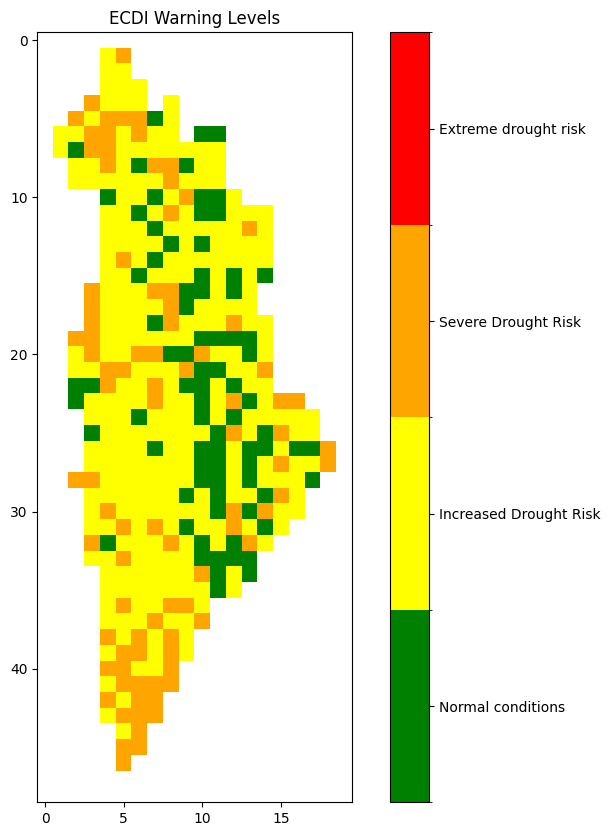

In [19]:
fig, ax = plt.subplots(figsize=(10, 10))

colors = ['green', 'yellow', 'orange', 'red']
cmap = mpl.colors.ListedColormap(colors)
bounds = [warning_levels_masked.min().item(), 0.5, 1.5, 2.5, warning_levels_masked.max().item()]
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# Plot the data using the custom colormap
im = ax.imshow(warning_levels_masked.isel(dekad=-1), cmap=cmap, norm=norm)

cbar = fig.colorbar(im, ax=ax, orientation='vertical')
ticks = pd.Series(cbar.ax.get_yticks()).rolling(2).mean()[1:].values
tick_labels = ["Normal conditions", "Increased Drought Risk", "Severe Drought Risk", "Extreme drought risk"]
cbar.set_ticks(ticks=ticks, labels=tick_labels)

ax.set_title("ECDI Warning Levels")
# Show plot
plt.show()